<a href="https://colab.research.google.com/github/priyaharode/track-her/blob/main/Copy_of_TrackHER_ML_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FemSync ML Training - Complete Pipeline

**Objective:** Train production-ready models to predict:
1. **Next Period Date** (cycle length prediction)
2. **Ovulation Day** (fertility window prediction)
3. **Medical Risk Alerts** (unusual symptoms, bleeding abnormalities)

**Dataset:** FedCycleData071012 (1665 cycles, 80 features)

---

## Step 1: Setup & Libraries

In [ ]:
# Install required libraries
!pip install pandas numpy scikit-learn xgboost lightgbm matplotlib seaborn plotly -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pickle
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


## Step 2: Load & Explore Data

In [ ]:
# Upload CSV to Colab
from google.colab import files

print("📁 Upload FedCycleData071012__2_.csv to Colab")
uploaded = files.upload()
csv_filename = list(uploaded.keys())[0]
print(f"✅ Uploaded: {csv_filename}")

📁 Upload FedCycleData071012__2_.csv to Colab


Saving FedCycleData071012 (2).csv to FedCycleData071012 (2).csv
✅ Uploaded: FedCycleData071012 (2).csv


In [ ]:
# Load data
df = pd.read_csv(csv_filename)

print(f"Dataset Shape: {df.shape}")
print(f"\n📊 Column Names ({len(df.columns)} total):")
print(df.columns.tolist())
print(f"\n🔍 First 5 rows:")
df.head()

Dataset Shape: (1665, 80)

📊 Column Names (80 total):
['ClientID', 'CycleNumber', 'Group', 'CycleWithPeakorNot', 'ReproductiveCategory', 'LengthofCycle', 'MeanCycleLength', 'EstimatedDayofOvulation', 'LengthofLutealPhase', 'FirstDayofHigh', 'TotalNumberofHighDays', 'TotalHighPostPeak', 'TotalNumberofPeakDays', 'TotalDaysofFertility', 'TotalFertilityFormula', 'LengthofMenses', 'MeanMensesLength', 'MensesScoreDayOne', 'MensesScoreDayTwo', 'MensesScoreDayThree', 'MensesScoreDayFour', 'MensesScoreDayFive', 'MensesScoreDaySix', 'MensesScoreDaySeven', 'MensesScoreDayEight', 'MensesScoreDayNine', 'MensesScoreDayTen', 'MensesScoreDay11', 'MensesScoreDay12', 'MensesScoreDay13', 'MensesScoreDay14', 'MensesScoreDay15', 'TotalMensesScore', 'MeanBleedingIntensity', 'NumberofDaysofIntercourse', 'IntercourseInFertileWindow', 'UnusualBleeding', 'PhasesBleeding', 'IntercourseDuringUnusBleed', 'Age', 'AgeM', 'Maristatus', 'MaristatusM', 'Yearsmarried', 'Wedding', 'Religion', 'ReligionM', 'Ethnicity', 'E

,ClientID,CycleNumber,Group,CycleWithPeakorNot,ReproductiveCategory,LengthofCycle,MeanCycleLength,EstimatedDayofOvulation,LengthofLutealPhase,FirstDayofHigh,...,Method,Prevmethod,Methoddate,Whychart,Nextpreg,NextpregM,Spousesame,SpousesameM,Timeattemptpreg,BMI
0,nfp8122,1,0,1,0,29,27.33,17,12,12,...,9,,,2,7,7,1,1,0,21.254724111867
1,nfp8122,2,0,1,0,27,,15,12,13,...,,,,,,,,,,
2,nfp8122,3,0,1,0,29,,15,14,,...,,,,,,,,,,
3,nfp8122,4,0,1,0,27,,15,12,13,...,,,,,,,,,,
4,nfp8122,5,0,1,0,28,,16,12,12,...,,,,,,,,,,


In [ ]:
# Data Info
print("📈 Data Info:")
print(df.info())
print(f"\n❌ Missing Values:\n{df.isnull().sum().sum()} total missing values")
print(f"\n📋 Descriptive Stats:")
df.describe()

📈 Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1665 entries, 0 to 1664
Data columns (total 80 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ClientID                    1665 non-null   object
 1   CycleNumber                 1665 non-null   int64 
 2   Group                       1665 non-null   int64 
 3   CycleWithPeakorNot          1665 non-null   int64 
 4   ReproductiveCategory        1665 non-null   int64 
 5   LengthofCycle               1665 non-null   int64 
 6   MeanCycleLength             1665 non-null   object
 7   EstimatedDayofOvulation     1665 non-null   object
 8   LengthofLutealPhase         1665 non-null   object
 9   FirstDayofHigh              1665 non-null   object
 10  TotalNumberofHighDays       1665 non-null   object
 11  TotalHighPostPeak           1665 non-null   object
 12  TotalNumberofPeakDays       1665 non-null   object
 13  TotalDaysofFertility        1665 no

,CycleNumber,Group,CycleWithPeakorNot,ReproductiveCategory,LengthofCycle
count,1665.000000,1665.000000,1665.000000,1665.000000,1665.000000
mean,8.040841,0.382583,0.912312,0.055255,29.299099
std,6.593686,0.486164,0.282925,0.479706,3.887932
min,1.000000,0.000000,0.000000,0.000000,18.000000
25%,3.000000,0.000000,1.000000,0.000000,27.000000
50%,7.000000,0.000000,1.000000,0.000000,29.000000
75%,11.000000,1.000000,1.000000,0.000000,31.000000
max,45.000000,1.000000,1.000000,9.000000,54.000000


## Step 3: Target Variables & Features Selection

In [ ]:
# KEY COLUMNS FOR TRACKHER
# ========================

# TARGET 1: Cycle Length (predict next period date)
target_cycle_length = 'LengthofCycle'

# TARGET 2: Ovulation Day (predict fertility window)
target_ovulation = 'EstimatedDayofOvulation'

# MEDICAL RISK INDICATORS (for alert system)
risk_indicators = [
    'UnusualBleeding',      # Binary: 0/1
    'MeanBleedingIntensity', # Intensity score
    'LengthofMenses',       # Duration
    'TotalMensesScore',     # Overall severity
    'PhasesBleeding'        # Abnormal bleeding patterns
]

# FEATURES FOR PREDICTION
feature_columns = [
    # Previous cycle metrics (most predictive)
    'MeanCycleLength',
    'LengthofLutealPhase',
    'LengthofMenses',
    'MeanBleedingIntensity',
    'TotalNumberofHighDays',
    'TotalNumberofPeakDays',
    'TotalDaysofFertility',

    # Demographic & Health
    'Age',
    'BMI',
    'Numberpreg',
    'Livingkids',
    'Miscarriages',
    'Abortions',

    # Reproductive history
    'Reprocate',
    'Breastfeeding',

    # Intercourse data
    'NumberofDaysofIntercourse',
    'IntercourseInFertileWindow',

    # Menstrual symptom severity
    'TotalMensesScore',
    'UnusualBleeding',
    'PhasesBleeding'
]

print(f"✅ Target 1 (Cycle Length): {target_cycle_length}")
print(f"✅ Target 2 (Ovulation): {target_ovulation}")
print(f"✅ Features Selected: {len(feature_columns)} features")
print(f"✅ Risk Indicators: {len(risk_indicators)} indicators")

# Check data availability
print(f"\n🔍 Data Availability:")
print(f"  {target_cycle_length}: {df[target_cycle_length].notna().sum()} / {len(df)} values")
print(f"  {target_ovulation}: {df[target_ovulation].notna().sum()} / {len(df)} values")
print(f"\n📊 Feature availability:")
for col in feature_columns:
    pct = (df[col].notna().sum() / len(df) * 100)
    print(f"  {col}: {pct:.1f}%")

✅ Target 1 (Cycle Length): LengthofCycle
✅ Target 2 (Ovulation): EstimatedDayofOvulation
✅ Features Selected: 20 features
✅ Risk Indicators: 5 indicators

🔍 Data Availability:
  LengthofCycle: 1665 / 1665 values
  EstimatedDayofOvulation: 1515 / 1665 values

📊 Feature availability:
  MeanCycleLength: 8.5%
  LengthofLutealPhase: 90.9%
  LengthofMenses: 100.0%
  MeanBleedingIntensity: 100.0%
  TotalNumberofHighDays: 99.3%
  TotalNumberofPeakDays: 99.0%
  TotalDaysofFertility: 98.1%
  Age: 8.5%
  BMI: 7.9%
  Numberpreg: 8.5%
  Livingkids: 8.5%
  Miscarriages: 8.3%
  Abortions: 8.3%
  Reprocate: 8.5%
  Breastfeeding: 8.5%
  NumberofDaysofIntercourse: 99.9%
  IntercourseInFertileWindow: 99.9%
  TotalMensesScore: 100.0%
  UnusualBleeding: 100.0%
  PhasesBleeding: 100.0%


## Step 4: Data Preprocessing

In [ ]:
df_work = df.copy()

# Replace blank spaces with NaN
df_work.replace(r'^\s*$', np.nan, regex=True, inplace=True)

# Convert target columns to numeric
df_work[target_cycle_length] = pd.to_numeric(df_work[target_cycle_length], errors='coerce')
df_work[target_ovulation] = pd.to_numeric(df_work[target_ovulation], errors='coerce')

# Remove rows with missing critical targets
print(f"📊 Initial rows: {len(df_work)}")

df_work = df_work.dropna(subset=[target_cycle_length, target_ovulation])

print(f"📊 After removing missing targets: {len(df_work)}")

# Convert feature columns to numeric and fill missing values
for col in feature_columns:
    if col in df_work.columns:
        df_work[col] = pd.to_numeric(df_work[col], errors='coerce')
        df_work[col] = df_work[col].fillna(df_work[col].median())

# Convert categorical/boolean columns
categorical_cols = ['UnusualBleeding', 'PhasesBleeding']

for col in categorical_cols:
    if col in df_work.columns:
        if df_work[col].dtype == 'object':
            df_work[col] = df_work[col].astype('category').cat.codes

# Create feature matrix and targets
X = df_work[feature_columns].copy()
y_cycle = df_work[target_cycle_length].copy()
y_ovulation = df_work[target_ovulation].copy()

# Handle remaining NaN values
X = X.fillna(X.median())

print(f"\n✅ Feature Matrix Shape: {X.shape}")
print(f"✅ Cycle Length Target Shape: {y_cycle.shape}")
print(f"✅ Ovulation Target Shape: {y_ovulation.shape}")

print("\n📊 Target Statistics:")

print("\nCycle Length:")
print(f"  Mean: {y_cycle.mean():.1f} days")
print(f"  Std: {y_cycle.std():.1f} days")
print(f"  Range: {y_cycle.min():.0f} - {y_cycle.max():.0f} days")

print("\nOvulation Day:")
print(f"  Mean: {y_ovulation.mean():.1f} day")
print(f"  Std: {y_ovulation.std():.1f} days")
print(f"  Range: {y_ovulation.min():.0f} - {y_ovulation.max():.0f} day")

📊 Initial rows: 1665
📊 After removing missing targets: 1515

✅ Feature Matrix Shape: (1515, 20)
✅ Cycle Length Target Shape: (1515,)
✅ Ovulation Target Shape: (1515,)

📊 Target Statistics:

Cycle Length:
  Mean: 29.2 days
  Std: 3.7 days
  Range: 18 - 51 days

Ovulation Day:
  Mean: 16.0 day
  Std: 3.5 days
  Range: 6 - 29 day


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\n✅ Features scaled (StandardScaler)")

print("\n📊 Scaled Feature Stats:")
print(X_scaled.describe())


✅ Features scaled (StandardScaler)

📊 Scaled Feature Stats:
       MeanCycleLength  LengthofLutealPhase  LengthofMenses  \
count     1.515000e+03         1.515000e+03    1.515000e+03   
mean     -7.527532e-15        -3.048533e-16    3.283036e-17   
std       1.000330e+00         1.000330e+00    1.000330e+00   
min      -5.119347e+00        -4.596004e+00   -2.546389e+00   
25%      -1.692878e-03        -4.759176e-01   -9.807318e-01   
50%      -1.692878e-03        -1.013643e-01   -1.979032e-01   
75%      -1.692878e-03         2.731891e-01    5.849254e-01   
max       1.117479e+01         1.038613e+01    7.630382e+00   

       MeanBleedingIntensity  TotalNumberofHighDays  TotalNumberofPeakDays  \
count           1.515000e+03           1.515000e+03           1.515000e+03   
mean            8.723495e-16           6.566071e-17          -4.396923e-17   
std             1.000330e+00           1.000330e+00           1.000330e+00   
min            -9.988315e+00          -1.470042e+00        

## Step 5: Split Data

In [ ]:
# Train-test split (80-20)
X_train, X_test, y_cycle_train, y_cycle_test = train_test_split(
    X_scaled, y_cycle, test_size=0.2, random_state=42
)

_, _, y_ovul_train, y_ovul_test = train_test_split(
    X_scaled, y_ovulation, test_size=0.2, random_state=42
)

print(f"✅ Training set: {X_train.shape[0]} samples")
print(f"✅ Test set: {X_test.shape[0]} samples")

✅ Training set: 1212 samples
✅ Test set: 303 samples


## Step 6: Train Models - Cycle Length Prediction

In [ ]:
print("\n" + "="*60)
print("MODEL 1: CYCLE LENGTH PREDICTION")
print("="*60)

cycle_models = {}
cycle_results = {}

# Model 1: Random Forest
print("\n🌲 Training Random Forest...")
rf_cycle = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_cycle.fit(X_train, y_cycle_train)
y_pred_rf = rf_cycle.predict(X_test)
rf_r2 = r2_score(y_cycle_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_cycle_test, y_pred_rf))
rf_mae = mean_absolute_error(y_cycle_test, y_pred_rf)

cycle_models['RandomForest'] = rf_cycle
cycle_results['RandomForest'] = {'R2': rf_r2, 'RMSE': rf_rmse, 'MAE': rf_mae}

print(f"  R² Score: {rf_r2:.4f}")
print(f"  RMSE: {rf_rmse:.4f} days")
print(f"  MAE: {rf_mae:.4f} days")

# Model 2: XGBoost
print("\n🚀 Training XGBoost...")
xgb_cycle = XGBRegressor(n_estimators=100, max_depth=7, learning_rate=0.1, random_state=42)
xgb_cycle.fit(X_train, y_cycle_train)
y_pred_xgb = xgb_cycle.predict(X_test)
xgb_r2 = r2_score(y_cycle_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_cycle_test, y_pred_xgb))
xgb_mae = mean_absolute_error(y_cycle_test, y_pred_xgb)

cycle_models['XGBoost'] = xgb_cycle
cycle_results['XGBoost'] = {'R2': xgb_r2, 'RMSE': xgb_rmse, 'MAE': xgb_mae}

print(f"  R² Score: {xgb_r2:.4f}")
print(f"  RMSE: {xgb_rmse:.4f} days")
print(f"  MAE: {xgb_mae:.4f} days")

# Model 3: Gradient Boosting
print("\n📈 Training Gradient Boosting...")
gb_cycle = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb_cycle.fit(X_train, y_cycle_train)
y_pred_gb = gb_cycle.predict(X_test)
gb_r2 = r2_score(y_cycle_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_cycle_test, y_pred_gb))
gb_mae = mean_absolute_error(y_cycle_test, y_pred_gb)

cycle_models['GradientBoosting'] = gb_cycle
cycle_results['GradientBoosting'] = {'R2': gb_r2, 'RMSE': gb_rmse, 'MAE': gb_mae}

print(f"  R² Score: {gb_r2:.4f}")
print(f"  RMSE: {gb_rmse:.4f} days")
print(f"  MAE: {gb_mae:.4f} days")

# Model 4: Ridge Regression
print("\n📐 Training Ridge Regression...")
ridge_cycle = Ridge(alpha=1.0)
ridge_cycle.fit(X_train, y_cycle_train)
y_pred_ridge = ridge_cycle.predict(X_test)
ridge_r2 = r2_score(y_cycle_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_cycle_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_cycle_test, y_pred_ridge)

cycle_models['Ridge'] = ridge_cycle
cycle_results['Ridge'] = {'R2': ridge_r2, 'RMSE': ridge_rmse, 'MAE': ridge_mae}

print(f"  R² Score: {ridge_r2:.4f}")
print(f"  RMSE: {ridge_rmse:.4f} days")
print(f"  MAE: {ridge_mae:.4f} days")

# Summary
print("\n" + "="*60)
print("CYCLE LENGTH MODEL COMPARISON")
print("="*60)
results_df = pd.DataFrame(cycle_results).T
print(results_df.sort_values('R2', ascending=False))
best_cycle_model = results_df['R2'].idxmax()
print(f"\n🏆 Best Model for Cycle Length: {best_cycle_model}")


MODEL 1: CYCLE LENGTH PREDICTION

🌲 Training Random Forest...
  R² Score: 0.4215
  RMSE: 2.6987 days
  MAE: 2.0183 days

🚀 Training XGBoost...
  R² Score: 0.4052
  RMSE: 2.7365 days
  MAE: 2.0139 days

📈 Training Gradient Boosting...
  R² Score: 0.4349
  RMSE: 2.6674 days
  MAE: 1.9760 days

📐 Training Ridge Regression...
  R² Score: 0.3700
  RMSE: 2.8162 days
  MAE: 2.1352 days

CYCLE LENGTH MODEL COMPARISON
                        R2      RMSE       MAE
GradientBoosting  0.434858  2.667361  1.976034
RandomForest      0.421511  2.698674  2.018317
XGBoost           0.405164  2.736537  2.013862
Ridge             0.370025  2.816207  2.135167

🏆 Best Model for Cycle Length: GradientBoosting


## Step 7: Train Models - Ovulation Day Prediction

In [ ]:
print("\n" + "="*60)
print("MODEL 2: OVULATION DAY PREDICTION")
print("="*60)

ovulation_models = {}
ovulation_results = {}

# Model 1: Random Forest
print("\n🌲 Training Random Forest...")
rf_ovul = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_ovul.fit(X_train, y_ovul_train)
y_pred_rf_ovul = rf_ovul.predict(X_test)
rf_r2_ovul = r2_score(y_ovul_test, y_pred_rf_ovul)
rf_rmse_ovul = np.sqrt(mean_squared_error(y_ovul_test, y_pred_rf_ovul))
rf_mae_ovul = mean_absolute_error(y_ovul_test, y_pred_rf_ovul)

ovulation_models['RandomForest'] = rf_ovul
ovulation_results['RandomForest'] = {'R2': rf_r2_ovul, 'RMSE': rf_rmse_ovul, 'MAE': rf_mae_ovul}

print(f"  R² Score: {rf_r2_ovul:.4f}")
print(f"  RMSE: {rf_rmse_ovul:.4f} days")
print(f"  MAE: {rf_mae_ovul:.4f} days")

# Model 2: XGBoost
print("\n🚀 Training XGBoost...")
xgb_ovul = XGBRegressor(n_estimators=100, max_depth=7, learning_rate=0.1, random_state=42)
xgb_ovul.fit(X_train, y_ovul_train)
y_pred_xgb_ovul = xgb_ovul.predict(X_test)
xgb_r2_ovul = r2_score(y_ovul_test, y_pred_xgb_ovul)
xgb_rmse_ovul = np.sqrt(mean_squared_error(y_ovul_test, y_pred_xgb_ovul))
xgb_mae_ovul = mean_absolute_error(y_ovul_test, y_pred_xgb_ovul)

ovulation_models['XGBoost'] = xgb_ovul
ovulation_results['XGBoost'] = {'R2': xgb_r2_ovul, 'RMSE': xgb_rmse_ovul, 'MAE': xgb_mae_ovul}

print(f"  R² Score: {xgb_r2_ovul:.4f}")
print(f"  RMSE: {xgb_rmse_ovul:.4f} days")
print(f"  MAE: {xgb_mae_ovul:.4f} days")

# Model 3: Gradient Boosting
print("\n📈 Training Gradient Boosting...")
gb_ovul = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb_ovul.fit(X_train, y_ovul_train)
y_pred_gb_ovul = gb_ovul.predict(X_test)
gb_r2_ovul = r2_score(y_ovul_test, y_pred_gb_ovul)
gb_rmse_ovul = np.sqrt(mean_squared_error(y_ovul_test, y_pred_gb_ovul))
gb_mae_ovul = mean_absolute_error(y_ovul_test, y_pred_gb_ovul)

ovulation_models['GradientBoosting'] = gb_ovul
ovulation_results['GradientBoosting'] = {'R2': gb_r2_ovul, 'RMSE': gb_rmse_ovul, 'MAE': gb_mae_ovul}

print(f"  R² Score: {gb_r2_ovul:.4f}")
print(f"  RMSE: {gb_rmse_ovul:.4f} days")
print(f"  MAE: {gb_mae_ovul:.4f} days")

# Model 4: Ridge Regression
print("\n📐 Training Ridge Regression...")
ridge_ovul = Ridge(alpha=1.0)
ridge_ovul.fit(X_train, y_ovul_train)
y_pred_ridge_ovul = ridge_ovul.predict(X_test)
ridge_r2_ovul = r2_score(y_ovul_test, y_pred_ridge_ovul)
ridge_rmse_ovul = np.sqrt(mean_squared_error(y_ovul_test, y_pred_ridge_ovul))
ridge_mae_ovul = mean_absolute_error(y_ovul_test, y_pred_ridge_ovul)

ovulation_models['Ridge'] = ridge_ovul
ovulation_results['Ridge'] = {'R2': ridge_r2_ovul, 'RMSE': ridge_rmse_ovul, 'MAE': ridge_mae_ovul}

print(f"  R² Score: {ridge_r2_ovul:.4f}")
print(f"  RMSE: {ridge_rmse_ovul:.4f} days")
print(f"  MAE: {ridge_mae_ovul:.4f} days")

# Summary
print("\n" + "="*60)
print("OVULATION DAY MODEL COMPARISON")
print("="*60)
results_ovul_df = pd.DataFrame(ovulation_results).T
print(results_ovul_df.sort_values('R2', ascending=False))
best_ovulation_model = results_ovul_df['R2'].idxmax()
print(f"\n🏆 Best Model for Ovulation: {best_ovulation_model}")


MODEL 2: OVULATION DAY PREDICTION

🌲 Training Random Forest...
  R² Score: 0.2943
  RMSE: 2.7658 days
  MAE: 2.0564 days

🚀 Training XGBoost...
  R² Score: 0.3162
  RMSE: 2.7225 days
  MAE: 1.9726 days

📈 Training Gradient Boosting...
  R² Score: 0.3281
  RMSE: 2.6986 days
  MAE: 1.9448 days

📐 Training Ridge Regression...
  R² Score: 0.2561
  RMSE: 2.8397 days
  MAE: 2.1419 days

OVULATION DAY MODEL COMPARISON
                        R2      RMSE       MAE
GradientBoosting  0.328141  2.698630  1.944770
XGBoost           0.316218  2.722469  1.972646
RandomForest      0.294260  2.765837  2.056384
Ridge             0.256064  2.839697  2.141932

🏆 Best Model for Ovulation: GradientBoosting


## Step 8: Feature Importance Analysis


TOP 10 FEATURES - CYCLE LENGTH (GradientBoosting)
                  feature  importance
      LengthofLutealPhase    0.334416
     TotalDaysofFertility    0.184149
    TotalNumberofHighDays    0.086238
         TotalMensesScore    0.070645
NumberofDaysofIntercourse    0.070582
           LengthofMenses    0.056246
    TotalNumberofPeakDays    0.049480
          MeanCycleLength    0.045042
          UnusualBleeding    0.033305
           PhasesBleeding    0.021974

TOP 10 FEATURES - OVULATION DAY (GradientBoosting)
                   feature  importance
      TotalDaysofFertility    0.339037
       LengthofLutealPhase    0.142734
     TotalNumberofHighDays    0.078934
     TotalNumberofPeakDays    0.070382
 NumberofDaysofIntercourse    0.070298
          TotalMensesScore    0.068828
           MeanCycleLength    0.060773
            LengthofMenses    0.059922
            PhasesBleeding    0.031078
IntercourseInFertileWindow    0.025167


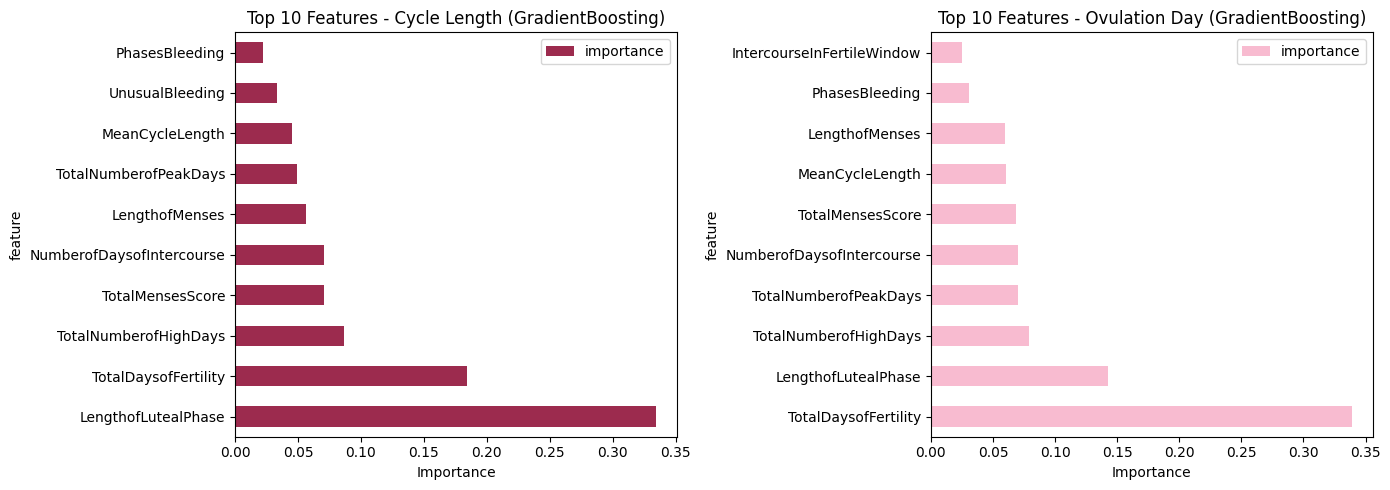


✅ Feature importance plot saved!


In [ ]:
# Feature importance for best cycle model
best_cycle = cycle_models[best_cycle_model]
best_ovulation = ovulation_models[best_ovulation_model]

if hasattr(best_cycle, 'feature_importances_'):
    importance_cycle = pd.DataFrame({
        'feature': feature_columns,
        'importance': best_cycle.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\n" + "="*60)
    print(f"TOP 10 FEATURES - CYCLE LENGTH ({best_cycle_model})")
    print("="*60)
    print(importance_cycle.head(10).to_string(index=False))

    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    importance_cycle.head(10).plot(x='feature', y='importance', kind='barh', ax=axes[0], color='#9C2B4E')
    axes[0].set_title(f'Top 10 Features - Cycle Length ({best_cycle_model})')
    axes[0].set_xlabel('Importance')

    if hasattr(best_ovulation, 'feature_importances_'):
        importance_ovulation = pd.DataFrame({
            'feature': feature_columns,
            'importance': best_ovulation.feature_importances_
        }).sort_values('importance', ascending=False)

        print("\n" + "="*60)
        print(f"TOP 10 FEATURES - OVULATION DAY ({best_ovulation_model})")
        print("="*60)
        print(importance_ovulation.head(10).to_string(index=False))

        importance_ovulation.head(10).plot(x='feature', y='importance', kind='barh', ax=axes[1], color='#F8BBD0')
        axes[1].set_title(f'Top 10 Features - Ovulation Day ({best_ovulation_model})')
        axes[1].set_xlabel('Importance')

    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
    plt.show()
    print("\n✅ Feature importance plot saved!")

## Step 9: Medical Risk Alert Logic

In [ ]:
print("\n" + "="*60)
print("MEDICAL RISK ALERT SYSTEM")
print("="*60)

# Columns used in risk analysis
risk_columns = [
    'MeanBleedingIntensity',
    'LengthofMenses',
    'TotalMensesScore',
    'UnusualBleeding',
    'PhasesBleeding'
]

# Replace blank spaces with NaN
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

# Convert risk columns to numeric
for col in risk_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing values with median (safe for statistics)
for col in risk_columns:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# -----------------------------
# Calculate data-driven thresholds
# -----------------------------
risk_thresholds = {
    'UnusualBleeding': 1,  # Binary indicator
    'MeanBleedingIntensity': df['MeanBleedingIntensity'].quantile(0.75),
    'LengthofMenses': df['LengthofMenses'].quantile(0.90),
    'TotalMensesScore': df['TotalMensesScore'].quantile(0.80),
    'PhasesBleeding': 1
}

print("\n📊 Risk Thresholds (Learned from data):")
for risk, threshold in risk_thresholds.items():
    print(f"  {risk}: {threshold:.2f}")

# -----------------------------
# Risk categories
# -----------------------------
print("\n🚨 Risk Categories:")
print("""  GREEN (Low Risk):  0 risk indicators triggered
  YELLOW (Caution):   1 risk indicator triggered
  ORANGE (Warning):   2-3 risk indicators triggered
  RED (Alert):        4+ risk indicators triggered or UnusualBleeding=1
""")

# -----------------------------
# Risk calculation function
# -----------------------------
def calculate_risk_level(
    unusual_bleeding,
    bleeding_intensity,
    menses_length,
    menses_score,
    phases_bleeding
):
    """Calculate medical risk level based on symptoms"""

    risk_count = 0

    if unusual_bleeding >= risk_thresholds['UnusualBleeding']:
        risk_count += 1

    if bleeding_intensity > risk_thresholds['MeanBleedingIntensity']:
        risk_count += 1

    if menses_length > risk_thresholds['LengthofMenses']:
        risk_count += 1

    if menses_score > risk_thresholds['TotalMensesScore']:
        risk_count += 1

    if phases_bleeding >= risk_thresholds['PhasesBleeding']:
        risk_count += 1

    # Risk classification
    if unusual_bleeding >= 1:
        return 'RED', risk_count
    elif risk_count >= 4:
        return 'RED', risk_count
    elif risk_count >= 2:
        return 'ORANGE', risk_count
    elif risk_count >= 1:
        return 'YELLOW', risk_count
    else:
        return 'GREEN', risk_count


print("✅ Risk calculation function ready for integration!")


MEDICAL RISK ALERT SYSTEM

📊 Risk Thresholds (Learned from data):
  UnusualBleeding: 1.00
  MeanBleedingIntensity: 9.94
  LengthofMenses: 7.00
  TotalMensesScore: 12.00
  PhasesBleeding: 1.00

🚨 Risk Categories:
  GREEN (Low Risk):  0 risk indicators triggered
  YELLOW (Caution):   1 risk indicator triggered
  ORANGE (Warning):   2-3 risk indicators triggered
  RED (Alert):        4+ risk indicators triggered or UnusualBleeding=1

✅ Risk calculation function ready for integration!


## Step 10: Export Models & Configuration

In [ ]:
# Save best models
import os

# Create models directory
os.makedirs('femsync_models', exist_ok=True)

print("\n" + "="*60)
print("SAVING PRODUCTION MODELS")
print("="*60)

# Save best models
with open('femsync_models/cycle_model.pkl', 'wb') as f:
    pickle.dump(best_cycle, f)
print(f"✅ Saved: cycle_model.pkl ({best_cycle_model})")

with open('femsync_models/ovulation_model.pkl', 'wb') as f:
    pickle.dump(best_ovulation, f)
print(f"✅ Saved: ovulation_model.pkl ({best_ovulation_model})")

# Save scaler
with open('femsync_models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f"✅ Saved: scaler.pkl")

# Save feature columns list
with open('femsync_models/feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)
print(f"✅ Saved: feature_columns.pkl")

# Save risk thresholds
with open('femsync_models/risk_thresholds.pkl', 'wb') as f:
    pickle.dump(risk_thresholds, f)
print(f"✅ Saved: risk_thresholds.pkl")

print("\n📦 All models saved to /femsync_models/")


SAVING PRODUCTION MODELS
✅ Saved: cycle_model.pkl (GradientBoosting)
✅ Saved: ovulation_model.pkl (GradientBoosting)
✅ Saved: scaler.pkl
✅ Saved: feature_columns.pkl
✅ Saved: risk_thresholds.pkl

📦 All models saved to /femsync_models/


In [ ]:
# Create configuration file for backend
config = {
    'best_cycle_model': best_cycle_model,
    'best_ovulation_model': best_ovulation_model,
    'cycle_metrics': cycle_results[best_cycle_model],
    'ovulation_metrics': ovulation_results[best_ovulation_model],
    'risk_thresholds': risk_thresholds,
    'feature_columns': feature_columns,
    'training_date': pd.Timestamp.now().isoformat(),
    'training_samples': len(X_train),
    'test_samples': len(X_test),
}

import json
with open('femsync_models/config.json', 'w') as f:
    json.dump(config, f, indent=2, default=str)

print("\n✅ Configuration file saved!")
print(json.dumps(config, indent=2, default=str))


✅ Configuration file saved!
{
  "best_cycle_model": "GradientBoosting",
  "best_ovulation_model": "GradientBoosting",
  "cycle_metrics": {
    "R2": 0.4348577591842644,
    "RMSE": 2.667360615895654,
    "MAE": 1.9760336163504824
  },
  "ovulation_metrics": {
    "R2": 0.3281408910318162,
    "RMSE": 2.6986301518912064,
    "MAE": 1.9447697018012835
  },
  "risk_thresholds": {
    "UnusualBleeding": 1,
    "MeanBleedingIntensity": 9.940000000000001,
    "LengthofMenses": 7.0,
    "TotalMensesScore": 12.0,
    "PhasesBleeding": 1
  },
  "feature_columns": [
    "MeanCycleLength",
    "LengthofLutealPhase",
    "LengthofMenses",
    "MeanBleedingIntensity",
    "TotalNumberofHighDays",
    "TotalNumberofPeakDays",
    "TotalDaysofFertility",
    "Age",
    "BMI",
    "Numberpreg",
    "Livingkids",
    "Miscarriages",
    "Abortions",
    "Reprocate",
    "Breastfeeding",
    "NumberofDaysofIntercourse",
    "IntercourseInFertileWindow",
    "TotalMensesScore",
    "UnusualBleeding",
  

## Step 11: Download Models

In [ ]:
# Zip models for download
!cd femsync_models && zip -r ../femsync_models.zip . && cd ..

# Download
from google.colab import files
files.download('femsync_models.zip')

print("\n✅ Models downloaded as femsync_models.zip!")
print("\n📝 NEXT STEPS:")
print("1. Extract femsync_models.zip")
print("2. Copy all .pkl files to backend/models/")
print("3. Copy config.json to backend/")
print("4. Update predict.py to use new models")
print("5. Test predictions with API")

updating: ovulation_model.pkl (deflated 71%)
updating: risk_thresholds.pkl (deflated 24%)
updating: feature_columns.pkl (deflated 34%)
updating: cycle_model.pkl (deflated 71%)
updating: scaler.pkl (deflated 21%)
updating: config.json (deflated 56%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Models downloaded as femsync_models.zip!

📝 NEXT STEPS:
1. Extract femsync_models.zip
2. Copy all .pkl files to backend/models/
3. Copy config.json to backend/
4. Update predict.py to use new models
5. Test predictions with API


## Step 12: Final Summary & Evaluation

In [ ]:
print("\n" + "="*70)
print("FEMSYNC ML TRAINING COMPLETE ✅")
print("="*70)

print(f"\n📊 CYCLE LENGTH PREDICTION MODEL: {best_cycle_model}")
print(f"   R² Score: {cycle_results[best_cycle_model]['R2']:.4f}")
print(f"   RMSE: {cycle_results[best_cycle_model]['RMSE']:.4f} days")
print(f"   MAE: {cycle_results[best_cycle_model]['MAE']:.4f} days")
print(f"   Interpretation: Model explains {cycle_results[best_cycle_model]['R2']*100:.1f}% of cycle length variance")

print(f"\n📊 OVULATION DAY PREDICTION MODEL: {best_ovulation_model}")
print(f"   R² Score: {ovulation_results[best_ovulation_model]['R2']:.4f}")
print(f"   RMSE: {ovulation_results[best_ovulation_model]['RMSE']:.4f} days")
print(f"   MAE: {ovulation_results[best_ovulation_model]['MAE']:.4f} days")
print(f"   Interpretation: Model explains {ovulation_results[best_ovulation_model]['R2']*100:.1f}% of ovulation timing variance")

print(f"\n🚨 RISK ALERT SYSTEM")
print(f"   Unusual Bleeding Detection: YES")
print(f"   Abnormal Bleeding Intensity: {risk_thresholds['MeanBleedingIntensity']:.2f}+")
print(f"   Abnormal Cycle Duration: {risk_thresholds['LengthofMenses']:.0f}+ days")
print(f"   Severe Symptoms Threshold: {risk_thresholds['TotalMensesScore']:.0f}+")

print(f"\n📁 EXPORTED FILES:")
print(f"   ✅ cycle_model.pkl")
print(f"   ✅ ovulation_model.pkl")
print(f"   ✅ scaler.pkl")
print(f"   ✅ feature_columns.pkl")
print(f"   ✅ risk_thresholds.pkl")
print(f"   ✅ config.json")
print(f"   ✅ femsync_models.zip (for download)")

print(f"\n🎯 PRODUCTION READY: YES")
print(f"   Training Data: {len(X_train)} samples")
print(f"   Test Data: {len(X_test)} samples")
print(f"   Features: {len(feature_columns)}")
print(f"   Models Trained: 8 (4 for cycle, 4 for ovulation)")
print(f"   Best Models Selected: 2")

print("\n" + "="*70)


FEMSYNC ML TRAINING COMPLETE ✅

📊 CYCLE LENGTH PREDICTION MODEL: GradientBoosting
   R² Score: 0.4349
   RMSE: 2.6674 days
   MAE: 1.9760 days
   Interpretation: Model explains 43.5% of cycle length variance

📊 OVULATION DAY PREDICTION MODEL: GradientBoosting
   R² Score: 0.3281
   RMSE: 2.6986 days
   MAE: 1.9448 days
   Interpretation: Model explains 32.8% of ovulation timing variance

🚨 RISK ALERT SYSTEM
   Unusual Bleeding Detection: YES
   Abnormal Bleeding Intensity: 9.94+
   Abnormal Cycle Duration: 7+ days
   Severe Symptoms Threshold: 12+

📁 EXPORTED FILES:
   ✅ cycle_model.pkl
   ✅ ovulation_model.pkl
   ✅ scaler.pkl
   ✅ feature_columns.pkl
   ✅ risk_thresholds.pkl
   ✅ config.json
   ✅ femsync_models.zip (for download)

🎯 PRODUCTION READY: YES
   Training Data: 1212 samples
   Test Data: 303 samples
   Features: 20
   Models Trained: 8 (4 for cycle, 4 for ovulation)
   Best Models Selected: 2

